In [8]:
# === IMPORTS ===================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


## EDA

In [9]:
train = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv")
test  = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv")
ss    = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/sample_submission.csv")
OPTS  = ['A','B','C','D','E']

print(f"train: {train.shape} | test: {test.shape} | sample sub: {ss.shape}")
print(f"missing in train: {train.isna().sum().sum()}, in test: {test.isna().sum().sum()}")
print(f"unique answers: {sorted(train['answer'].unique())}")
print(f"answer distribution:\n{train['answer'].value_counts().reindex(OPTS)}")


train: (2000, 8) | test: (2000, 8) | sample sub: (500, 2)
missing in train: 0, in test: 0
unique answers: ['A', 'B', 'C', 'D', 'E']
answer distribution:
answer
A    369
B    490
C    459
D    358
E    324
Name: count, dtype: int64


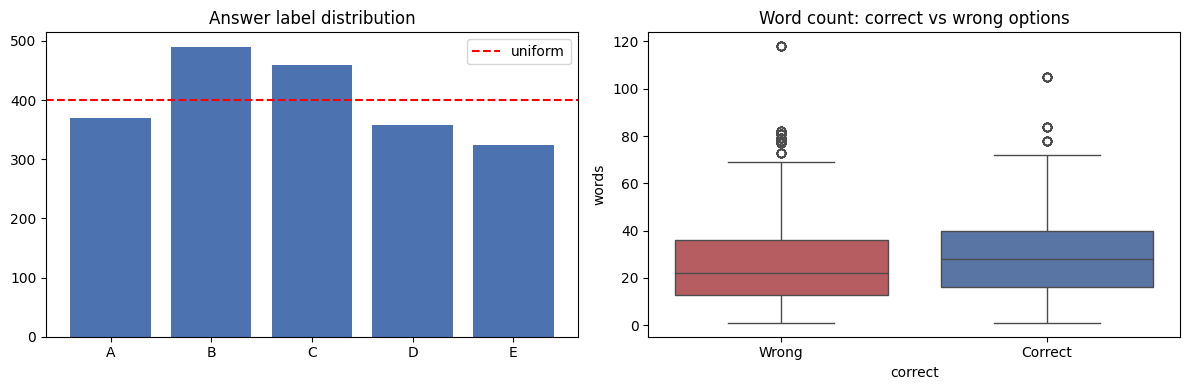

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ans_dist = train['answer'].value_counts().reindex(OPTS).fillna(0)

ax[0].bar(ans_dist.index, ans_dist.values, color='#4C72B0')
ax[0].axhline(len(train)/5, color='red', ls='--', label='uniform')
ax[0].set_title('Answer label distribution')
ax[0].legend()

rows = []
for _, r in train.iterrows():
    for c in OPTS:
        rows.append({
            'correct': 'Correct' if c == r['answer'] else 'Wrong',
            'words': len(str(r[c]).split())
        })

df_l = pd.DataFrame(rows)

sns.boxplot(
    data=df_l,
    x='correct',
    y='words',
    hue='correct',
    legend=False,
    ax=ax[1],
    palette=['#C44E52', '#4C72B0']
)

ax[1].set_title('Word count: correct vs wrong options')
plt.tight_layout()
plt.show()